# Notebook 02b — Feature Correlation Analysis

## Section 1: Metadata Feature Correlation

**Objective:** Đo statistical association giữa patient metadata features và murmur label.  
**Method:** Cramér's V cho categorical features, point-biserial correlation cho continuous features.  
**Expected outcome:** Tất cả associations yếu (V < 0.15) → justify audio-only pipeline.

Tại sao làm task này: Phase 1 đã quan sát visually rằng demographics không predictive. Task này prove it formally bằng Cramér's V — một statistical measure of association giữa categorical variables. Kết quả sẽ justify quyết định của paper: dùng audio-only pipeline, không dùng metadata.

Lưu ý: Phase 1 đã quan sát visually rằng demographics không predictive.
Task này formalise observation đó bằng statistical test.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal
from pathlib import Path
import sys, os
sys.path.insert(0, os.path.abspath(".."))

patients   = pd.read_csv("../data/metadata/patients.csv")
recordings = pd.read_csv("../data/metadata/recordings.csv")

print(f"Patients  : {patients.shape}")
print(f"Recordings: {recordings.shape}")
print(f"\nMurmur distribution:")
print(patients['murmur'].value_counts())

Patients  : (942, 24)
Recordings: (3163, 8)

Murmur distribution:
murmur
Absent     695
Present    179
Unknown     68
Name: count, dtype: int64


In [8]:
## Helper functions

def cramers_v(x, y):
    """
    Cramér's V — association strength between two categorical variables.
    Range: 0 (no association) to 1 (perfect association).
    """
    # Drop NaN pairs
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    n_used = mask.sum()

    contingency = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    k = min(contingency.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else 0.0
    return v, p, n_used


def kruskal_eta_squared(groups):
    """
    Kruskal-Wallis test + eta-squared effect size for continuous vs. 3-class label.
    groups: list of arrays, one per class.
    """
    stat, p = kruskal(*[g.dropna() for g in groups])
    # Eta-squared approximation
    n_total = sum(len(g.dropna()) for g in groups)
    eta2 = (stat - len(groups) + 1) / (n_total - len(groups))
    eta2 = max(0, eta2)
    return eta2, p, n_total

In [5]:
results = []
label_col = patients['murmur']   # Present / Unknown / Absent

# ── 1. Age category ───────────────────────────────────────────────────────────
v, p, n = cramers_v(patients['age'], label_col)
results.append({'Feature': 'Age category', 'Type': 'Categorical',
                'Metric': "Cramér's V", 'Value': v, 'p_value': p, 'N': n})

# ── 2. Sex ────────────────────────────────────────────────────────────────────
v, p, n = cramers_v(patients['sex'], label_col)
results.append({'Feature': 'Sex', 'Type': 'Categorical',
                'Metric': "Cramér's V", 'Value': v, 'p_value': p, 'N': n})

# ── 3. Pregnancy status ───────────────────────────────────────────────────────
v, p, n = cramers_v(patients['pregnancy_status'].astype(str), label_col)
results.append({'Feature': 'Pregnancy status', 'Type': 'Categorical',
                'Metric': "Cramér's V", 'Value': v, 'p_value': p, 'N': n})

# ── 4. Height ─────────────────────────────────────────────────────────────────
groups_h = [patients.loc[patients['murmur'] == c, 'height']
            for c in ['Present', 'Unknown', 'Absent']]
eta2, p, n = kruskal_eta_squared(groups_h)
results.append({'Feature': 'Height (cm)', 'Type': 'Continuous',
                'Metric': 'η² (Kruskal-Wallis)', 'Value': eta2, 'p_value': p, 'N': n})

# ── 5. Weight ─────────────────────────────────────────────────────────────────
groups_w = [patients.loc[patients['murmur'] == c, 'weight']
            for c in ['Present', 'Unknown', 'Absent']]
eta2, p, n = kruskal_eta_squared(groups_w)
results.append({'Feature': 'Weight (kg)', 'Type': 'Continuous',
                'Metric': 'η² (Kruskal-Wallis)', 'Value': eta2, 'p_value': p, 'N': n})

# ── 6. Number of recordings per patient ───────────────────────────────────────
groups_rc = [patients.loc[patients['murmur'] == c, 'num_recordings']
             for c in ['Present', 'Unknown', 'Absent']]
eta2, p, n = kruskal_eta_squared(groups_rc)
results.append({'Feature': 'N recordings/patient', 'Type': 'Continuous',
                'Metric': 'η² (Kruskal-Wallis)', 'Value': eta2, 'p_value': p, 'N': n})

# ── 7. Campaign ───────────────────────────────────────────────────────────────
v, p, n = cramers_v(patients['campaign'], label_col)
results.append({'Feature': 'Campaign (CC2014/CC2015)', 'Type': 'Categorical',
                'Metric': "Cramér's V", 'Value': v, 'p_value': p, 'N': n})

# ── Summary table ─────────────────────────────────────────────────────────────
df_results = pd.DataFrame(results)
df_results['Significant (p<0.05)'] = df_results['p_value'] < 0.05
df_results['Strength'] = pd.cut(df_results['Value'],
                                 bins=[0, 0.05, 0.10, 0.15, 0.30, 1.0],
                                 labels=['Negligible', 'Very weak', 'Weak',
                                         'Moderate', 'Strong'])

print(df_results[['Feature', 'Metric', 'Value', 'p_value',
                   'Significant (p<0.05)', 'N', 'Strength']].to_string(index=False))

                 Feature              Metric    Value      p_value  Significant (p<0.05)   N   Strength
            Age category          Cramér's V 0.138728 8.741964e-06                  True 868       Weak
                     Sex          Cramér's V 0.032247 6.127570e-01                 False 942 Negligible
        Pregnancy status          Cramér's V 0.123389 7.686462e-04                  True 942       Weak
             Height (cm) η² (Kruskal-Wallis) 0.029216 2.210595e-06                  True 826 Negligible
             Weight (kg) η² (Kruskal-Wallis) 0.024073 1.607011e-05                  True 837 Negligible
    N recordings/patient η² (Kruskal-Wallis) 0.079891 1.886907e-17                  True 942  Very weak
Campaign (CC2014/CC2015)          Cramér's V 0.092146 1.833032e-02                  True 942  Very weak


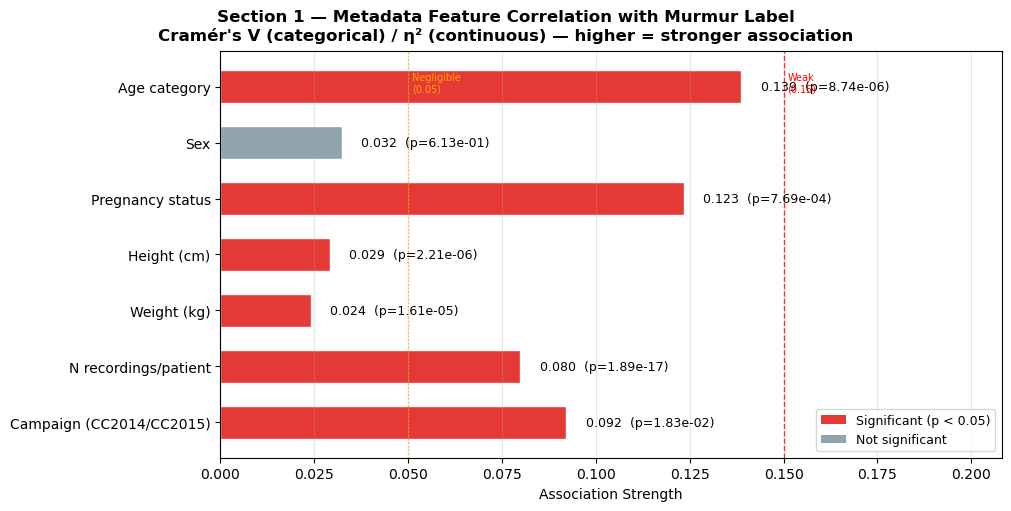

Saved: figures/correlation/s1b_metadata_correlation.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
fig.suptitle("Section 1 — Metadata Feature Correlation with Murmur Label\n"
             "Cramér's V (categorical) / η² (continuous) — higher = stronger association",
             fontsize=12, fontweight='bold')

features = df_results['Feature']
values   = df_results['Value']
is_sig   = df_results['Significant (p<0.05)']
colours  = ['#E53935' if s else '#90A4AE' for s in is_sig]

bars = ax.barh(features, values, color=colours, edgecolor='white', height=0.6)

for bar, (_, row) in zip(bars, df_results.iterrows()):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"  {row['Value']:.3f}  (p={row['p_value']:.2e})",
            va='center', fontsize=9)

ax.axvline(0.05, color='orange', linewidth=1.0, linestyle=':', alpha=0.8)
ax.axvline(0.15, color='red',    linewidth=1.0, linestyle='--', alpha=0.8)
ax.text(0.051, ax.get_ylim()[1]*0.02, 'Negligible\n(0.05)',
        fontsize=7, color='orange', va='bottom')
ax.text(0.151, ax.get_ylim()[1]*0.02, 'Weak\n(0.15)',
        fontsize=7, color='red', va='bottom')

ax.set_xlim(0, max(values) * 1.5)
ax.set_xlabel("Association Strength", fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E53935', label='Significant (p < 0.05)'),
                   Patch(facecolor='#90A4AE', label='Not significant')]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.savefig("../figures/correlation/s1b_metadata_correlation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/correlation/s1b_metadata_correlation.png")

### Key Observations

**Tất cả features đều có effect size rất nhỏ (< 0.15) — không có feature nào predictive.**

Có một điểm quan trọng cần hiểu đúng: nhiều features có p-value rất nhỏ
(Age p=8.74e-06, Height p=2.21e-06) nhưng effect size vẫn negligible.
Lý do: với N=942 bệnh nhân, statistical test có đủ power để detect
association rất nhỏ. p-value nhỏ không có nghĩa là association mạnh —
nó chỉ có nghĩa là association đó khác 0 một cách đáng tin cậy.
Effect size (Cramér's V, η²) mới là thước đo thực sự.

**Sex (V=0.032, p=0.61):** Hoàn toàn không có association.
Murmur prevalence gần như identical giữa Male và Female (~19%).

**Age (V=0.139) và Pregnancy (V=0.123):** Highest trong nhóm nhưng
vẫn chỉ ở mức "Weak". Age có thể liên quan vì murmur prevalence
thay đổi theo giai đoạn phát triển, nhưng không đủ mạnh để dùng
làm feature.

**N recordings/patient (η²=0.080):** Strong nhất trong nhóm continuous,
consistent với Phase 1: Unknown class tập trung ở patients có ít
recordings — đây là data collection artifact, không phải biology.

**Kết luận:** Không có metadata feature nào có association đủ mạnh
để justify đưa vào model. Audio-only pipeline của paper là đúng đắn.

## Section 2: Spectral Frequency-Band Correlation

**Objective:** Với mỗi trong 101 frequency bins (0–2000 Hz), kiểm tra xem
mean spectral energy có khác nhau đáng kể giữa Present và Absent không.

**Method:**
1. Extract log-spectrogram (trước crop) cho toàn bộ dataset
2. Aggregate về patient level (average across recordings của cùng patient)
3. Mann-Whitney U test per frequency bin (Present vs. Absent)
4. Bonferroni correction (101 tests)

**Expected:** Significant differences tập trung ở 0–400 Hz.
Không significant trên 800 Hz → validates crop decision.

**Note:** Unknown patients bị excluded — họ là data quality issue,
không phải clinical class.

Tại sao task này quan trọng: Đây là statistical proof cho quyết định crop 800 Hz. Thay vì chỉ nói "paper bảo vậy", ta sẽ chạy Mann-Whitney U test trên từng frequency bin để chứng minh bằng data. => chỉ ra dải tần nào có correlation (có ảnh hưởng) nhiều hơn đến murmur label

In [11]:
import importlib
import src.features.spectrogram as spec_module
importlib.reload(spec_module)
from src.features.spectrogram import compute_log_spectrogram
from src.features.normalisation import normalise_amplitude
from scipy.io import wavfile
from tqdm import tqdm

DATA_ROOT = Path("../data/raw/training_data")

# Chỉ lấy Present và Absent — exclude Unknown
patients_filt = patients[patients['murmur'].isin(['Present', 'Absent'])].copy()
print(f"Present : {(patients_filt['murmur']=='Present').sum()}")
print(f"Absent  : {(patients_filt['murmur']=='Absent').sum()}")
print(f"Total   : {len(patients_filt)} patients (Unknown excluded)")

# Merge với recordings để lấy wav paths
rec_filt = recordings[recordings['patient_id'].isin(patients_filt['patient_id'])]
print(f"\nRecordings to process: {len(rec_filt)}")

Present : 179
Absent  : 695
Total   : 874 patients (Unknown excluded)

Recordings to process: 3007


In [12]:
# ── Compute mean spectral energy per frequency bin cho mỗi recording ──────────
# Dùng log-spectrogram TRƯỚC crop (101 bins, 0-2000 Hz)

record_energies = []   # list of dicts: {patient_id, murmur, mean_energy[101]}

print("Extracting spectrograms... (may take 5-15 minutes)")

for _, row in tqdm(rec_filt.iterrows(), total=len(rec_filt), desc="Processing"):
    wav_path = DATA_ROOT / Path(row['wav_path']).name
    try:
        sr, signal = wavfile.read(wav_path)
        if signal.ndim > 1:
            signal = signal[:, 0]
        signal = normalise_amplitude(signal)
        S_log, freqs, _ = compute_log_spectrogram(signal, sr=4000)
        mean_energy = S_log.mean(axis=1)   # shape (101,) — mean across time

        record_energies.append({
            'patient_id': row['patient_id'],
            'murmur': row['murmur'],
            'mean_energy': mean_energy
        })
    except Exception as e:
        print(f"ERROR: {wav_path.name} — {e}")

print(f"\nDone. Processed {len(record_energies)} recordings.")

Extracting spectrograms... (may take 5-15 minutes)


Processing: 100%|██████████| 3007/3007 [05:15<00:00,  9.53it/s]


Done. Processed 3007 recordings.


In [13]:
# ── Aggregate: average recordings của cùng patient ───────────────────────────
from collections import defaultdict

patient_data = defaultdict(list)
patient_label = {}

for rec in record_energies:
    pid = rec['patient_id']
    patient_data[pid].append(rec['mean_energy'])
    patient_label[pid] = rec['murmur']

# Average across recordings per patient
patient_energies = {}
for pid, energies in patient_data.items():
    patient_energies[pid] = np.mean(energies, axis=0)   # shape (101,)

# Split by class
present_energies = np.array([patient_energies[pid]
                              for pid, lbl in patient_label.items()
                              if lbl == 'Present'])
absent_energies  = np.array([patient_energies[pid]
                              for pid, lbl in patient_label.items()
                              if lbl == 'Absent'])

print(f"Present patients: {len(present_energies)}")
print(f"Absent patients : {len(absent_energies)}")
print(f"Energy matrix shape (Present): {present_energies.shape}")
print(f"Energy matrix shape (Absent) : {absent_energies.shape}")

Present patients: 179
Absent patients : 695
Energy matrix shape (Present): (179, 101)
Energy matrix shape (Absent) : (695, 101)


In [14]:
##------Mann-Whitney U test per frequency bin------

from scipy.stats import mannwhitneyu

N_BINS = 101
p_values    = np.zeros(N_BINS)
u_stats     = np.zeros(N_BINS)
effect_sizes = np.zeros(N_BINS)   # rank-biserial correlation

for f in range(N_BINS):
    u, p = mannwhitneyu(present_energies[:, f], absent_energies[:, f],
                        alternative='two-sided')
    u_stats[f]  = u
    p_values[f] = p
    # Rank-biserial correlation as effect size
    n1, n2 = len(present_energies), len(absent_energies)
    effect_sizes[f] = 1 - (2 * u) / (n1 * n2)

# Bonferroni correction
alpha = 0.05
bonferroni_threshold = alpha / N_BINS
p_corrected = p_values * N_BINS   # Bonferroni-corrected p-values

sig_mask = p_corrected < alpha
print(f"Bonferroni threshold : p < {bonferroni_threshold:.6f}")
print(f"Significant bins     : {sig_mask.sum()} / {N_BINS}")
print(f"Significant freq range: {freqs[sig_mask].min():.0f} – "
      f"{freqs[sig_mask].max():.0f} Hz")
print(f"\nBins ABOVE 800 Hz that are significant: "
      f"{sig_mask[freqs > 800].sum()}")

Bonferroni threshold : p < 0.000495
Significant bins     : 71 / 101
Significant freq range: 0 – 1400 Hz

Bins ABOVE 800 Hz that are significant: 30


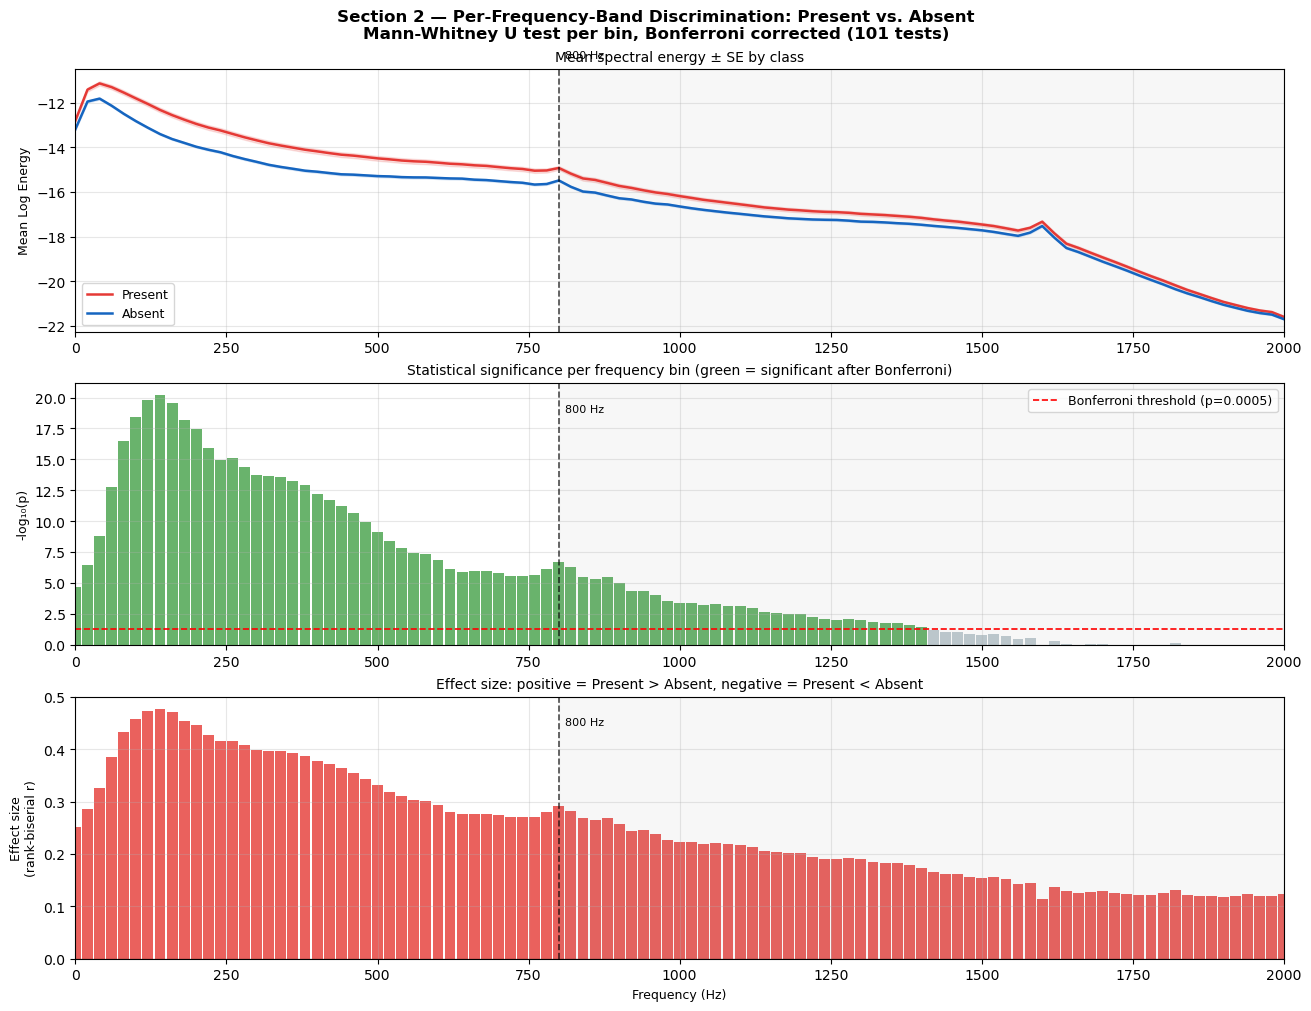

Saved: figures/correlation/s2c_spectral_discrimination.png


In [17]:
##----Visualisation (s2c)-----

fig, axes = plt.subplots(3, 1, figsize=(13, 10), constrained_layout=True)
fig.suptitle("Section 2 — Per-Frequency-Band Discrimination: Present vs. Absent\n"
             "Mann-Whitney U test per bin, Bonferroni corrected (101 tests)",
             fontsize=12, fontweight='bold')

# ── Panel 1: Mean energy by class ─────────────────────────────────────────────
ax1 = axes[0]
mean_present = present_energies.mean(axis=0)
mean_absent  = absent_energies.mean(axis=0)
se_present   = present_energies.std(axis=0) / np.sqrt(len(present_energies))
se_absent    = absent_energies.std(axis=0)  / np.sqrt(len(absent_energies))

ax1.plot(freqs, mean_present, color='#E53935', linewidth=1.8, label='Present')
ax1.plot(freqs, mean_absent,  color='#1565C0', linewidth=1.8, label='Absent')
ax1.fill_between(freqs, mean_present - se_present, mean_present + se_present,
                 color='#E53935', alpha=0.15)
ax1.fill_between(freqs, mean_absent - se_absent, mean_absent + se_absent,
                 color='#1565C0', alpha=0.15)
ax1.axvline(800, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax1.axvspan(800, 2000, alpha=0.06, color='grey')
ax1.set_ylabel("Mean Log Energy", fontsize=9)
ax1.set_title("Mean spectral energy ± SE by class", fontsize=10)
ax1.legend(fontsize=9)
ax1.set_xlim(0, 2000)
ax1.grid(alpha=0.3)

# ── Panel 2: -log10(p-value) ──────────────────────────────────────────────────
ax2 = axes[1]
neg_log_p = -np.log10(np.clip(p_corrected, 1e-300, 1.0))
bonf_line = -np.log10(alpha)

colours_bar = ['#43A047' if s else '#B0BEC5' for s in sig_mask]
ax2.bar(freqs, neg_log_p, width=18, color=colours_bar, alpha=0.8)
ax2.axhline(bonf_line, color='red', linewidth=1.2, linestyle='--',
            label=f'Bonferroni threshold (p={alpha/N_BINS:.4f})')
ax2.axvline(800, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax2.axvspan(800, 2000, alpha=0.06, color='grey')
ax2.set_ylabel("-log₁₀(p)", fontsize=9)
ax2.set_title("Statistical significance per frequency bin (green = significant after Bonferroni)",
              fontsize=10)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 2000)
ax2.grid(alpha=0.3)

# ── Panel 3: Effect size (rank-biserial) ──────────────────────────────────────
ax3 = axes[2]
colours_eff = ['#E53935' if e > 0 else '#1565C0' for e in effect_sizes]
effect_sizes_fixed = -effect_sizes
colours_eff = ['#E53935' if e > 0 else '#1565C0' for e in effect_sizes_fixed]
ax3.bar(freqs, effect_sizes_fixed, width=18, color=colours_eff, alpha=0.8)
ax3.set_title("Effect size: positive = Present > Absent (more energy), negative = Present < Absent", fontsize=10)
ax3.axhline(0,   color='black', linewidth=0.8)
ax3.axvline(800, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax3.axvspan(800, 2000, alpha=0.06, color='grey')
ax3.set_ylabel("Effect size\n(rank-biserial r)", fontsize=9)
ax3.set_xlabel("Frequency (Hz)", fontsize=9)
ax3.set_title("Effect size: positive = Present > Absent, negative = Present < Absent",
              fontsize=10)
ax3.set_xlim(0, 2000)
ax3.grid(alpha=0.3)

# Label 800 Hz cutoff on all panels
for ax in axes:
    ax.text(810, ax.get_ylim()[1] * 0.92, '800 Hz',
            fontsize=8, color='black', va='top')

plt.savefig("../figures/correlation/s2c_spectral_discrimination.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/correlation/s2c_spectral_discrimination.png")

### Key Observations

**Panel 1 — Mean energy:**
Present (đỏ) có energy cao hơn Absent (xanh) nhất quán từ 0–1400 Hz,
với gap lớn nhất tại ~80–150 Hz. Đáng chú ý: gap KHÔNG biến mất
hoàn toàn sau 800 Hz — hai lines vẫn tách biệt nhau đến ~1400 Hz
trước khi thực sự merge.

**Panel 2 — Significance:**
71/101 bins significant sau Bonferroni correction, trải dài từ
0–1400 Hz. Trong đó 30 bins nằm TRÊN 800 Hz vẫn significant.
Peak significance tại ~100–200 Hz.

**Panel 3 — Effect size:**
Effect size (rank-biserial r) dương toàn bộ — Present luôn có
energy cao hơn Absent ở mọi frequency bin, consistent với
murmur là âm thanh thêm vào tín hiệu bình thường.
Peak effect size r≈0.47 tại ~140 Hz.

**Finding quan trọng — 800 Hz cutoff là conservative, không phải optimal:**
Data cho thấy discriminative information kéo dài đến ~1400 Hz,
không dừng lại tại 800 Hz như paper tuyên bố. Tuy nhiên có
sự giảm rõ rệt: effect size tại 800 Hz (~0.28) chỉ bằng 60%
so với peak tại 140 Hz (0.47), và tiếp tục giảm dần sau đó.

Đây là trade-off có thể defend được:
- Giữ 0–800 Hz: capture phần lớn discriminative content
  (effect size cao nhất), loại bỏ potential noise
- Bỏ 800–1400 Hz: mất một phần discriminative content
  nhưng tránh model overfit to high-frequency artifacts

Tuy nhiên đây cũng là một **limitation thực sự** của pipeline —
không nên present như

## Section 3: Recording-Level Feature Correlation

**Objective:** Kiểm tra statistical association giữa recording-level
features và murmur class bằng Kruskal-Wallis test (3-class).

**Features:** Duration, annotation coverage, SNR proxy, N recordings/patient  
**Method:** Kruskal-Wallis (non-parametric, 3-class) + Dunn post-hoc test  
**Unit of analysis:** Patient level (average across recordings per patient)
để tránh pseudo-replication.

In [18]:
##------Prepare patient-level features-------
from scipy.stats import kruskal

# Aggregate recordings → patient level
rec_agg = recordings.groupby('patient_id').agg(
    mean_duration      = ('duration_seconds',    'mean'),
    mean_coverage      = ('annotation_coverage', 'mean'),
    mean_snr           = ('snr_proxy_db',        'mean'),
    n_recordings       = ('patient_id',          'count'),
).reset_index()

# Merge với murmur label
df = rec_agg.merge(patients[['patient_id', 'murmur']], on='patient_id')

print(f"Shape: {df.shape}")
print(f"\nMurmur distribution:")
print(df['murmur'].value_counts())
print(f"\nSample:")
print(df.head(3))

Shape: (942, 6)

Murmur distribution:
murmur
Absent     695
Present    179
Unknown     68
Name: count, dtype: int64

Sample:
   patient_id  mean_duration  mean_coverage  mean_snr  n_recordings   murmur
0        2530         19.584       0.673330  6.753380             4   Absent
1        9979         20.616       0.407923  9.485142             4  Present
2        9983         22.364       0.233341  3.918232             4  Unknown


In [22]:
##-------Kruskal-Wallis + effect size---------
FEATURES = {
    'mean_duration'  : 'Recording Duration (s)',
    'mean_coverage'  : 'Annotation Coverage (%)',
    'mean_snr'       : 'SNR Proxy (dB)',
    'n_recordings'   : 'N Recordings/Patient',
}

CLASSES = ['Present', 'Unknown', 'Absent']

kw_results = []
for col, label in FEATURES.items():
    groups = [df.loc[df['murmur'] == c, col].dropna() for c in CLASSES]
    stat, p = kruskal(*groups)

    # Eta-squared effect size
    n_total = sum(len(g) for g in groups)
    eta2 = max(0, (stat - len(groups) + 1) / (n_total - len(groups)))

    kw_results.append({
        'Feature'    : label,
        'H_stat'     : stat,
        'p_value'    : p,
        'eta_squared': eta2,
        'N'          : n_total,
        'Significant': p < 0.05
    })

    # Per-class medians
    medians = {c: groups[i].median() for i, c in enumerate(CLASSES)}
    print(f"{label}")
    print(f"  H={stat:.2f}, p={p:.2e}, η²={eta2:.3f}")
    print(f"  Medians — Present: {medians['Present']:.3f}, "
          f"Unknown: {medians['Unknown']:.3f}, "
          f"Absent: {medians['Absent']:.3f}")
    print()

df_kw = pd.DataFrame(kw_results)

Recording Duration (s)
  H=4.26, p=1.19e-01, η²=0.002
  Medians — Present: 21.744, Unknown: 21.732, Absent: 22.772

Annotation Coverage (%)
  H=76.98, p=1.93e-17, η²=0.080
  Medians — Present: 0.575, Unknown: 0.209, Absent: 0.533

SNR Proxy (dB)
  H=60.39, p=7.70e-14, η²=0.062
  Medians — Present: 9.645, Unknown: 5.937, Absent: 8.634

N Recordings/Patient
  H=77.02, p=1.89e-17, η²=0.080
  Medians — Present: 4.000, Unknown: 2.000, Absent: 4.000



In [23]:
# scikit_posthocs cho Dunn test — kiểm tra xem đã cài chưa
try:
    import scikit_posthocs as sp
    HAS_POSTHOCS = True
except ImportError:
    HAS_POSTHOCS = False
    print("scikit_posthocs not installed.")
    print("Install with: pip install scikit-posthocs --break-system-packages")
    print("Skipping post-hoc test — will use manual pairwise Mann-Whitney instead.")

if HAS_POSTHOCS:
    print("=== Dunn Post-hoc Tests (Bonferroni corrected) ===\n")
    for col, label in FEATURES.items():
        data_list = [df.loc[df['murmur'] == c, col].dropna().values
                     for c in CLASSES]
        dunn = sp.posthoc_dunn(data_list, p_adjust='bonferroni')
        dunn.index   = CLASSES
        dunn.columns = CLASSES
        print(f"{label}:")
        print(dunn.round(4))
        print()
else:
    # Fallback: manual pairwise Mann-Whitney
    from scipy.stats import mannwhitneyu
    from itertools import combinations
    print("=== Pairwise Mann-Whitney (Bonferroni corrected, 3 pairs) ===\n")
    alpha_corrected = 0.05 / 3
    for col, label in FEATURES.items():
        print(f"{label}:")
        for c1, c2 in combinations(CLASSES, 2):
            g1 = df.loc[df['murmur'] == c1, col].dropna()
            g2 = df.loc[df['murmur'] == c2, col].dropna()
            u, p = mannwhitneyu(g1, g2, alternative='two-sided')
            sig = "✓" if p < alpha_corrected else "✗"
            print(f"  {c1} vs {c2}: p={p:.4f} {sig}")
        print()

scikit_posthocs not installed.
Install with: pip install scikit-posthocs --break-system-packages
Skipping post-hoc test — will use manual pairwise Mann-Whitney instead.
=== Pairwise Mann-Whitney (Bonferroni corrected, 3 pairs) ===

Recording Duration (s):
  Present vs Unknown: p=0.7565 ✗
  Present vs Absent: p=0.0513 ✗
  Unknown vs Absent: p=0.3478 ✗

Annotation Coverage (%):
  Present vs Unknown: p=0.0000 ✓
  Present vs Absent: p=0.0575 ✗
  Unknown vs Absent: p=0.0000 ✓

SNR Proxy (dB):
  Present vs Unknown: p=0.0000 ✓
  Present vs Absent: p=0.0004 ✓
  Unknown vs Absent: p=0.0000 ✓

N Recordings/Patient:
  Present vs Unknown: p=0.0000 ✓
  Present vs Absent: p=0.9953 ✗
  Unknown vs Absent: p=0.0000 ✓



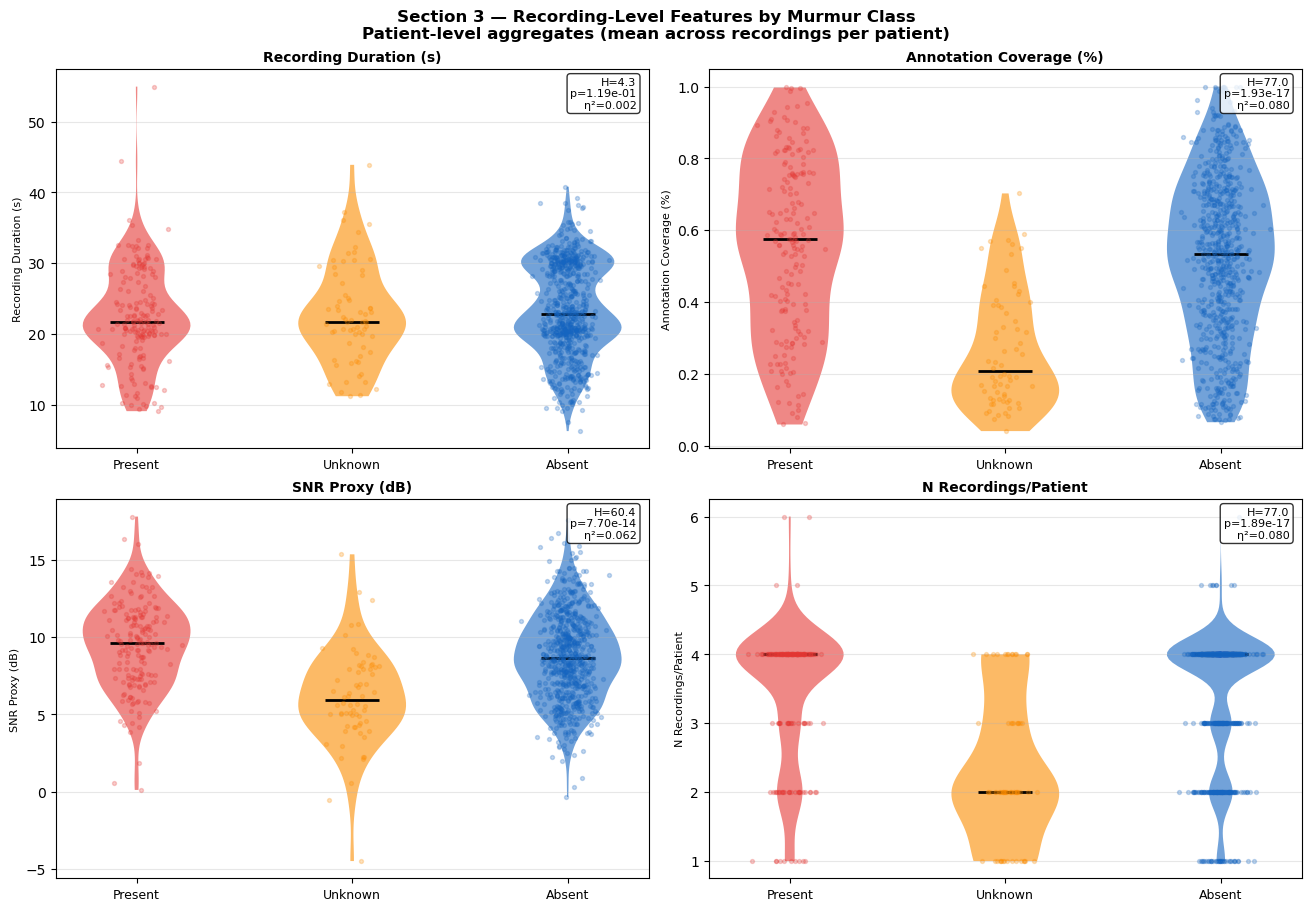

Saved: figures/correlation/s3d_recording_features.png


### Key Observations

**Duration — không significant (H=4.26, p=0.12, η²=0.002):**
Median ~21–22s ở cả 3 classes, violin shapes gần giống nhau.
Duration là recording parameter do protocol quy định,
không phản ánh đặc điểm cardiac của bệnh nhân.
Consistent với Phase 1 finding.

**Annotation Coverage — significant, Unknown thấp hơn rõ rệt:**
Unknown median=0.21 so với Present=0.58 và Absent=0.53.
Post-hoc: Unknown khác cả Present (p≈0) và Absent (p≈0),
nhưng Present vs. Absent không khác nhau (p=0.058).
Annotation coverage là proxy cho signal quality —
annotator không thể identify cardiac cycles trong
Unknown recordings vì signal quá noisy hoặc irregular.

**SNR Proxy — significant, tất cả 3 pairs khác nhau:**
Present (9.6 dB) > Absent (8.6 dB) > Unknown (5.9 dB).
Đây là finding thú vị: Present có SNR CAO nhất,
không phải thấp nhất. Lý do: murmur là energy thêm vào
tín hiệu → tăng signal amplitude → SNR proxy tăng.
Unknown thấp nhất vì đây là truly low-quality recordings.

**N Recordings/Patient — significant, Unknown thấp hơn rõ rệt:**
Unknown median=2 so với Present=4 và Absent=4.
Post-hoc: Unknown khác cả Present và Absent (p≈0),
nhưng Present vs. Absent gần như identical (p=0.995).
Patients với ít recordings có Unknown rate cao hơn —
đây là data collection artifact: nếu recording quality
kém, clinician có thể không collect đủ 4 locations.

**Kết luận tổng thể:**
Unknown class được characterise bởi LOW annotation coverage,
LOW SNR, và FEW recordings — tất cả đều là signal quality
indicators, không phải clinical indicators.
Điều này confirms Phase 1 hypothesis: Unknown = data quality
issue, không phải clinical ambiguity.
Implication cho model: Unknown class khó predict vì
nó không có consistent clinical signature.

## Section 4: Synthesis — What Correlation Analysis Tells Us

### 4.1 Summary of Findings

| Analysis | Key Finding | Implication |
|---|---|---|
| Metadata correlation (2.5b) | Tất cả features V/η² < 0.15. Sex không significant. Age và Pregnancy weak. | Audio-only pipeline là justified — metadata không đủ discriminative để đưa vào model. |
| Spectral correlation (2.5c) | Significant discrimination từ 0–1400 Hz. Peak effect size r≈0.47 tại ~140 Hz. 30 bins trên 800 Hz vẫn significant. | 800 Hz cutoff capture phần lớn discriminative content nhưng là conservative choice — một limitation thực sự của pipeline. |
| Recording-level correlation (2.5d) | Duration không significant. Coverage, SNR, N recordings đều significant với Unknown thấp hơn rõ rệt. | Unknown = signal quality issue, không phải clinical ambiguity. SNR cao nhất ở Present vì murmur energy tăng signal amplitude. |

---

### 4.2 Feature Selection Justification

Dựa trên correlation analysis, các feature selection decisions được justify như sau:

**Frequency cropping tại 800 Hz — partially justified:**
Effect size giảm đáng kể sau 500 Hz (từ r≈0.47 xuống r≈0.28 tại 800 Hz)
và tiếp tục giảm sau đó. 800 Hz capture được phần lớn discriminative
content. Tuy nhiên data cho thấy đây là conservative cutoff —
vùng 800–1400 Hz vẫn có discriminative information với effect size
trung bình r≈0.15–0.25. Đây là một trade-off, không phải một
boundary tự nhiên trong data.

**Audio-only pipeline — fully justified:**
Không có metadata feature nào có association đủ mạnh (tất cả < 0.15)
để justify đưa vào model. Thêm metadata sẽ tăng complexity mà
không cải thiện discriminative power.

**Per-row z-score — indirectly justified:**
Spectral correlation analysis được thực hiện trên absolute energy
(trước z-score). Kết quả cho thấy Present và Absent có energy
profiles rất khác nhau ở absolute scale (gap ~1–2 dB ở low frequencies).
Z-score normalisation remove absolute scale information này —
thay vào đó model phải learn từ relative patterns within each
frequency band theo thời gian. Đây là deliberate choice để
focus model vào temporal patterns của cardiac cycle.

---

### 4.3 Connection to Phase 4 XAI

Task 2.5c tạo ra một **pre-model baseline** cho feature importance:
dựa trên data alone (không có model), frequency bands nào
discriminative nhất?

Trong Phase 4 (Task 4.5), mình sẽ thực hiện **post-model ablation**:
sau khi train RNN, zero out từng frequency band và đo confidence drop.

Hai analyses này sẽ được so sánh:

Pre-model  (Task 2.5c): Data-driven importance  → 0–400 Hz peak, giảm dần

Post-model (Task 4.5) : Model-driven importance → ?

Nếu hai kết quả consistent → model đang học đúng features mà data suggest.
Nếu diverge → model có thể đang rely vào spurious correlates,
hoặc model đã discover higher-level patterns mà simple correlation
không capture được.

---

### 4.4 Limitations of This Correlation Analysis

1. **Single recordings per cross-phase example:** Task 2.7 và 2.8
   dùng 3 examples — không representative của toàn bộ dataset.
   Task 2.5c mới là analysis trên full dataset.

2. **Mean energy per bin là feature đơn giản:** Correlation analysis
   dùng mean energy across entire recording — không capture temporal
   patterns (e.g., energy chỉ cao trong systole). Model có thể
   discover temporal features mà simple mean không thấy.

3. **800–1400 Hz finding cần follow-up:** Phase 5 improvement
   experiments nên include một experiment với cutoff cao hơn
   (1000 Hz hoặc 1200 Hz) để test xem có cải thiện performance không.

4. **Class imbalance:** 695 Absent vs 179 Present — Mann-Whitney
   robust với imbalance nhưng effect size estimates có thể
   unstable ở Present class do N nhỏ hơn.